# New PLM generation drawing site from entropy

In [1]:
import numpy as np
import torch
import os, platform
import sys
import matplotlib.pyplot as plt
from seq_utils import read_tensor_from_txt, set_seed


In [2]:
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.insert(0, parent_dir)
from model import AttentionModel
from model_PCA_correlation import AttentionModel_PCA
from model_PCA_cond import ModelPCAcondJ
from dcascore import *
from utils import quickread
from attention import trainer, trainerCondJ, trainer_PCA_comp_2_model, ar_trainer # choose trainer


# back to original path (in PLM)
sys.path.pop(0)  # Removes the parent_dir from sys.path

'/Users/marzioformica/Desktop/EPFL/Master/StageLBS/PCA_gen_AI/CODE/AttentionDCA_python/src'

## Load Q,K,V

In [3]:
"""
    Load Q, K, V matrices from jdoms (after training)
"""
set_seed()
H = 64
d= 10
N = 174
n_epochs = 500
nb_PCA_comp=2
loss_type = 'without_J'
family = 'jdoms' #'jdoms_bacteria_train2'
cwd = parent_dir
Q_1 = read_tensor_from_txt( cwd +"/results/{H}_{d}_{family}_{losstype}_{n_epochs}_mod_alessandro/Q_tensor.txt".format(H=H, d=d, family=family, losstype=loss_type, n_epochs=n_epochs))
K_1 = read_tensor_from_txt( cwd +"/results/{H}_{d}_{family}_{losstype}_{n_epochs}_mod_alessandro/K_tensor.txt".format(H=H, d=d, family=family, losstype=loss_type, n_epochs=n_epochs))
V_1 = read_tensor_from_txt( cwd +"/results/{H}_{d}_{family}_{losstype}_{n_epochs}_mod_alessandro/V_tensor.txt".format(H=H, d=d, family=family, losstype=loss_type, n_epochs=n_epochs))
H,d,N=Q_1.shape
q=V_1.shape[1]

model=AttentionModel(H,d,N,q,Q=Q_1,V=V_1,K=K_1)
torch.sum(model.Q-Q_1)
device = Q_1.device
L = Q_1.shape[-1]
W=attention_heads_from_model(model,Q_1,K_1,V_1)
print(W.shape)

i_indices = torch.arange(L, device=device).unsqueeze(1)
j_indices = torch.arange(L, device=device).unsqueeze(0)
mask = (i_indices != j_indices).float().unsqueeze(0)  # shape (1, L, L)
# Mask only part without CPA
H, _, M = K_1.shape #(M=N+m)

#W[:,:,:-2] = W[:,:,:-2] * mask
W = W * mask

    
# Compute Jtens
Jtens = torch.einsum('hri,hab->abri', W, V_1)  # Shape: (q, q, L, L)
q = Jtens.shape[0]
N = Jtens.shape[2]
print(q)
print(N)
print(Jtens.shape)

torch.Size([64, 63, 63])
21
63
torch.Size([21, 21, 63, 63])


In [4]:
older_dir = os.path.abspath(os.path.join(current_dir, '..', '..', '..'))
Z,W = quickread(older_dir + '/DataAttentionDCA/jdoms/jdoms_bacteria_train2.fasta')

Total sequences read: 14502
Sequences after filtering: 14502
Sampling 100000 pairs out of 105146751 total pairs.
Mean fraction of identical positions (sampled): 0.37202728570888266
Computed theta: 0.3268577458459699


100%|██████████| 14502/14502 [00:18<00:00, 776.19it/s] 

3265.70225762244


In [5]:
def compute_empirical_freqs(Z: np.ndarray, W: np.ndarray, q: int) -> np.ndarray:
    """
    Compute empirical weighted frequencies.
    Z : ndarray of shape (N, M) with entries in [1..q]
    W : ndarray of shape (M,)
    q : alphabet size
    Returns: ndarray of shape (q, N)
    """
    N, M = Z.shape
    if W is None:
        W = np.ones(M) # divide by M at the end
        W = W / M
    else: 
        W = W / W.sum()  # Normalize weights to sum to 1
    # one-hot: (N, M, q)
    Z0 = Z - 1  # shift to 0-based indexing --- IGNORE ---
    one_hot = np.eye(q, dtype=float)[Z0]

    # Multiply weights (broadcast W along N and q)
    weighted = one_hot * W[None, :, None]  # (N, M, q)

    # Sum over sequences (axis=1), result shape (N, q)
    f = weighted.sum(axis=1).T  # (q, N)

    return f

(21, 63)
(63,)


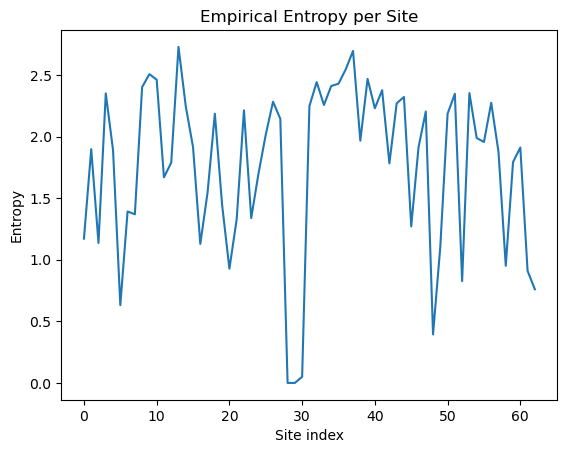

In [6]:
f_emp = compute_empirical_freqs(Z, W, q)
print(f_emp.shape)
probas = f_emp / f_emp.sum(axis=0, keepdims=True)
entropy = -np.sum(probas * np.log(probas + 1e-10), axis=0)  # Adding a small constant to avoid log(0)
print(entropy.shape)
plt.plot(entropy)
plt.xlabel('Site index')
plt.ylabel('Entropy')
plt.title('Empirical Entropy per Site')
plt.show()  

In [7]:
def site_probas(S, beta=1.0):
    """
    Compute site probabilities with temperature scaling.
    S : ndarray of shape (q, N) with empirical frequencies
    beta : inverse temperature
    Returns: ndarray of shape (q, N) with probabilities
    """
    p = np.exp(beta*S)
    probas = p / p.sum(axis=0, keepdims=True)
    return probas

p = site_probas(entropy, beta=1.0)

def beta_tanh(N_iter, N_tot, a=1):
    # calculate beta as tanh of iteration ratio
    ratio = N_iter / N_tot
    # shift so that tanh goes from -1 to 1
    print(a*(ratio-0.5))
    beta = np.tanh(a*(ratio-0.5))  # scale factor to adjust steepness
    return beta

-49.5


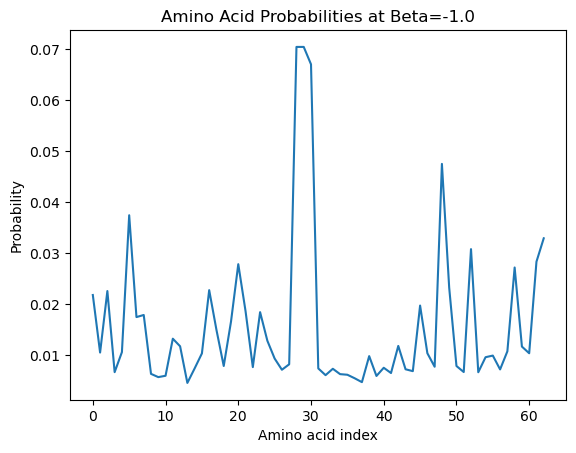

In [8]:
# test plot probas
beta = beta_tanh(1, 200, a=100)
p_test = site_probas(entropy, beta=beta)
# plot p_test for all sites
plt.plot(p_test)
plt.xlabel('Amino acid index')
plt.ylabel('Probability')
plt.title('Amino Acid Probabilities at Beta={}'.format(beta))
plt.show()

In [25]:
def generate_plm_vec(J, N_seqs=40000, init_sequence=None, beta=1, nb_PCA_comp=0, beta_pca = 0, target_coords=np.array([]), site_selector=None):
    """
    Generate N_seqs new sequences using PLM.

    Parameters
    ----------
    J : interaction tensor
    N_seqs : int
        Number of sequences to generate
    init_sequence : array-like
        Optional initial sequence
    beta : float
        Inverse temperature
    site_selector : function(seq) -> int
        Function to select site to update.
        If None, sites are chosen uniformly at random.
    """
    gen_sequences = []
    seq = SequencePLMvec(J, init_sequence, beta=beta, nb_PCA_comp=nb_PCA_comp, target_coords=target_coords, beta_PCA=beta_pca)

    for i in tqdm(range(N_seqs)):
        if site_selector is None:
            site = np.random.randint(seq.L)  # uniform random
        else:
            beta = beta_tanh(i, N_seqs, a=1)
            probas = site_probas(entropy, beta=beta)
            site = np.random.choice(seq.L, p=probas)  # weighted random
            #print("Selected site:", site)
            site = int(site)
        #seq.check_vectorized(site)
        seq.draw_aa(site, vec=True)
        gen_sequences.append(seq.sequence.copy())

    return np.array(gen_sequences)

In [31]:
class SequencePLMvec:
    def __init__(self, J, initial_sequence = None, beta = 1, nb_PCA_comp=0,target_coords=np.array([]),J_tens_PCA=None,beta_PCA=1):
        """
        Initialize the SequencePLM object with a coupling tensor J of the family and an optional initial sequence.
        """
        self.J = J
        self.J_PCA=J_tens_PCA
        #self.L = J.shape[-1]
        self.beta = beta
        self.beta_PCA=beta_PCA
        self.nb_PCA_comp=nb_PCA_comp
        if not (J_tens_PCA is None):
            if nb_PCA_comp!=J_tens_PCA.shape[-1]:
                print("Mismatch of PCA tensor and nb PCA components indicated")
        if J_tens_PCA is None:
            self.L = J.shape[-1] - nb_PCA_comp  # Length of the sequence without PCA components
        else:
            self.L = J.shape[-1]
        if initial_sequence is None:
            self.sequence = np.random.choice(np.arange(21), self.L) # Sequence of ints (1 to 21) 
            if len(target_coords)==nb_PCA_comp:
                self.sequence = np.concatenate((self.sequence,target_coords))
            else:
                print("number of PCA components doesn't match size of PCA list")
        else:
            self.sequence = initial_sequence

    def to_letter(self):
        """
        Show sequence as letters
        """
        print("Sequence:", self.sequence)
        num_to_letter = {v: k for k, v in letter_to_num.items()}
        letter_seq = ''.join([num_to_letter[i] for i in self.sequence[:len(self.sequence)-self.nb_PCA_comp]])
        print(letter_seq)
        return letter_seq

    def plm_calc(self, site, trial_aa):
        """
        Compute unnormalized pseudo-likelihood of trial_aa at a given site.
        site: int from 0 to L-1
        trial_aa: int from 0 to 21 (amino acid index)
        """
        if site < 0 or site >= self.L:
            raise ValueError(f"Site {site} is out of bounds for sequence length {self.L}.")
        sum_energy = 0.0
        if not ( self.J_PCA is None):      
            for i in range(self.nb_PCA_comp):
                    PCA_coord = self.sequence[self.L + i] 
                    sum_energy += self.beta_PCA * self.J_PCA[trial_aa, PCA_coord, site, i] # J_PCA of shape ([q, Nbins, L, nb_PCA_comp])
        else:
            for i in range(self.nb_PCA_comp):
                sum_energy+=self.beta_PCA*self.J[trial_aa,self.sequence[self.L+i],site,self.L+i] # J of shape ([q, q+Nbins, L, L+nb_PCA_comp])
        for j in range(self.L):
            if j == site:
                continue
            aa_j = self.sequence[j]
            sum_energy += self.beta * self.J[trial_aa, aa_j, site, j] 
        prob = sum_energy  
        return prob
    
    def plm_calc_vec(self, site):
        """
        Compute unnormalized pseudo-likelihoods for ALL trial amino acids at once.
        Returns array of shape (q,) with one score per amino acid.
        """
        q = 21
        # trial amino acids (0 to 20) (ints)
        trial_aas = np.arange(q)[:, None]  # (21,1)
        # --- Sequence couplings ---
        mask = np.arange(self.L) != site
        other_sites = np.arange(self.L)[mask]
        aa_vector = self.sequence[:self.L][mask]              # amino acids at other sites
        aa_vector = aa_vector.astype(int)
        #print("Site:", site)
        #print("Other sites:", other_sites)
        #print("AA vector:", aa_vector)
        #print("Trial AAs:", trial_aas)
        seq_energies = self.J[trial_aas, aa_vector, site, other_sites]  # (21, L-1)
        sum_energy = self.beta * np.sum(seq_energies, axis=1)           # (21,)

        # --- PCA couplings ---
        if self.nb_PCA_comp > 0:
            pca_indices = np.arange(self.L, self.L + self.nb_PCA_comp)  # j-axis indices
            pca_bins = self.sequence[pca_indices]                       # PCA bins

            if self.J_PCA is not None:
                # J_PCA: (q, Nbins, L, nb_PCA_comp)
                pca_energies = self.J_PCA[trial_aas, pca_bins, site, np.arange(self.nb_PCA_comp)]
            else:
                # J: (q, q+Nbins, L, L+nb_PCA_comp) — bins already shifted by q
                pca_energies = self.J[trial_aas, pca_bins, site, pca_indices]

            sum_energy += self.beta_PCA * np.sum(pca_energies, axis=1)

        return sum_energy
    
    def plm_site_distribution(self, site):
        """
        Compute probability distriution for specific site (normalized)
        """
        probs = []
        for trial_aa in range(21):
            probs.append(self.plm_calc(site, trial_aa))
        probs = np.array(probs)
        probs = np.exp(probs-probs.max()) #to avoid overflow for high beta
        probs /= probs.sum()
        return probs
    
    def plm_site_distribution_vec(self, site):
        """
        Compute probability distribution for specific site (normalized).
        """
        sum_energy = self.plm_calc_vec(site)  # (21,)
        probs = np.exp(sum_energy - np.max(sum_energy))  # stable softmax
        probs /= probs.sum()
        return probs
    def check_vectorized(self, site):
        """
        Check that vectorized and loop implementations give same result
        """
        probs_loop = self.plm_site_distribution(site)
        probs_vec = self.plm_site_distribution_vec(site)
        assert np.allclose(probs_loop, probs_vec), f"Mismatch at site {site}"
        print(f"Vectorized check passed at site {site}")

    def draw_aa(self, site, vec=True):
        """
        Sample a new AA at the given site from PLM distribution
        """
        if vec:
            probs = self.plm_site_distribution_vec(site)
        else:
            probs = self.plm_site_distribution(site)
        new_aa = np.random.choice(21, p=probs) # aa from 0 to 20
        new_aa = int(new_aa)
        self.sequence[site] = new_aa
    
    def seq_energy(self):
        sum=0
        for i in range(self.L):
            for j in range(self.L):
                sum+=self.J[self.sequence[i], self.sequence[j],i,j]
        return sum

In [ ]:
#from plm_model import SequencePLMvec
from tqdm import tqdm
generated_seqs = generate_plm_vec(Jtens.cpu().numpy(), N_seqs=500000, beta=1, site_selector=1)

  1%|          | 309/50000 [00:00<00:16, 3088.67it/s]

-0.5
-0.49998
-0.49996
-0.49994
-0.49992
-0.4999
-0.49988
-0.49986
-0.49984
-0.49982
-0.4998
-0.49978
-0.49976
-0.49974
-0.49972
-0.4997
-0.49968
-0.49966
-0.49964
-0.49962
-0.4996
-0.49958
-0.49956
-0.49954
-0.49952
-0.4995
-0.49948
-0.49946
-0.49944
-0.49942
-0.4994
-0.49938
-0.49936
-0.49934
-0.49932
-0.4993
-0.49928
-0.49926
-0.49924
-0.49922
-0.4992
-0.49918
-0.49916
-0.49914
-0.49912
-0.4991
-0.49908
-0.49906
-0.49904
-0.49902
-0.499
-0.49898
-0.49896
-0.49894
-0.49892
-0.4989
-0.49888
-0.49886
-0.49884
-0.49882
-0.4988
-0.49878
-0.49876
-0.49874
-0.49872
-0.4987
-0.49868
-0.49866
-0.49863999999999997
-0.49862
-0.4986
-0.49858
-0.49856
-0.49854
-0.49852
-0.4985
-0.49848
-0.49846
-0.49844
-0.49842
-0.4984
-0.49838
-0.49836
-0.49834
-0.49832
-0.4983
-0.49828
-0.49826
-0.49824
-0.49822
-0.4982
-0.49818
-0.49816
-0.49814
-0.49812
-0.4981
-0.49808
-0.49806
-0.49804
-0.49802
-0.498
-0.49798
-0.49796
-0.49794
-0.49792
-0.4979
-0.49788
-0.49786
-0.49784
-0.49782
-0.4978
-0.49778
-0.49776

  2%|▏         | 930/50000 [00:00<00:16, 3040.20it/s]

-0.48778
-0.48776
-0.48774
-0.48772
-0.4877
-0.48768
-0.48766
-0.48764
-0.48762
-0.4876
-0.48758
-0.48756
-0.48754
-0.48752
-0.4875
-0.48748
-0.48746
-0.48744
-0.48742
-0.4874
-0.48738
-0.48736
-0.48734
-0.48732
-0.4873
-0.48728
-0.48726
-0.48724
-0.48722
-0.4872
-0.48718
-0.48716
-0.48714
-0.48712
-0.4871
-0.48708
-0.48706
-0.48704000000000003
-0.48702
-0.487
-0.48698
-0.48696
-0.48694
-0.48692
-0.4869
-0.48688
-0.48686
-0.48684
-0.48682
-0.4868
-0.48678
-0.48676
-0.48674
-0.48672
-0.4867
-0.48668
-0.48666
-0.48664
-0.48662
-0.4866
-0.48658
-0.48656
-0.48654
-0.48652
-0.4865
-0.48648
-0.48646
-0.48644
-0.48642
-0.4864
-0.48638
-0.48636
-0.48634
-0.48632
-0.4863
-0.48628
-0.48626
-0.48624
-0.48622
-0.4862
-0.48618
-0.48616
-0.48614
-0.48612
-0.4861
-0.48608
-0.48606
-0.48604
-0.48602
-0.486
-0.48598
-0.48596
-0.48594
-0.48592
-0.4859
-0.48588
-0.48586
-0.48584
-0.48582
-0.4858
-0.48578
-0.48576
-0.48574
-0.48572
-0.4857
-0.48568
-0.48566
-0.48564
-0.48562
-0.4856
-0.48558
-0.48556
-0.4

  3%|▎         | 1573/50000 [00:00<00:16, 2973.29it/s]

...

0.47038
0.47040000000000004
0.47041999999999995
0.47043999999999997
0.47046
0.47048
0.47050000000000003
0.47052000000000005
0.47053999999999996
0.47056
0.47058
0.4706
0.47062000000000004
0.47063999999999995
0.47065999999999997
0.47068
0.4707
0.47072
0.47074000000000005
0.47075999999999996
0.47078
0.4708
0.47082
0.47084000000000004
0.47085999999999995
0.47087999999999997
0.4709
0.47092
0.47094
0.47096000000000005
0.47097999999999995
0.471
0.47102
0.47104
0.47106000000000003
0.47108000000000005
0.47109999999999996
0.47112
0.47114
0.47116
0.47118000000000004
0.47119999999999995
0.47121999999999997
0.47124
0.47126
0.47128000000000003
0.47130000000000005
0.47131999999999996
0.47134
0.47136
0.47138
0.47140000000000004
0.47141999999999995
0.47143999999999997
0.47146
0.47148
0.47150000000000003
0.47152000000000005
0.47153999999999996
0.47156
0.47158
0.4716
0.47162000000000004
0.47163999999999995
0.47165999999999997
0.47168
0.4717
0.47172000000000003
0.47174000000000005
0.47175999999999996
0.47

 99%|█████████▉| 49609/50000 [00:15<00:00, 3591.51it/s]

0.48463999999999996
0.48466
0.48468
0.4847
0.48472000000000004
0.48473999999999995
0.48475999999999997
0.48478
0.4848
0.48482000000000003
0.48484000000000005
0.48485999999999996
0.48488
0.4849
0.48492
0.48494000000000004
0.48495999999999995
0.48497999999999997
0.485
0.48502
0.48504
0.48506000000000005
0.48507999999999996
0.4851
0.48512
0.48514
0.48516000000000004
0.48517999999999994
0.48519999999999996
0.48522
0.48524
0.48526
0.48528000000000004
0.48529999999999995
0.48532
0.48534
0.48536
0.48538000000000003
0.48540000000000005
0.48541999999999996
0.48544
0.48546
0.48548
0.48550000000000004
0.48551999999999995
0.48553999999999997
0.48556
0.48558
0.48560000000000003
0.48562000000000005
0.48563999999999996
0.48566
0.48568
0.4857
0.48572000000000004
0.48573999999999995
0.48575999999999997
0.48578
0.4858
0.48582000000000003
0.48584000000000005
0.48585999999999996
0.48588
0.4859
0.48592
0.48594000000000004
0.48595999999999995
0.48597999999999997
0.486
0.48602
0.48604
0.48606000000000005
0.4

100%|██████████| 50000/50000 [00:15<00:00, 3278.20it/s]

0.49946
0.49948000000000004
0.49950000000000006
0.49951999999999996
0.49954
0.49956
0.49958
0.49960000000000004
0.49961999999999995
0.49964
0.49966
0.49968
0.49970000000000003
0.49972000000000005
0.49973999999999996
0.49976
0.49978
0.4998
0.49982000000000004
0.49983999999999995
0.49985999999999997
0.49988
0.4999
0.49992000000000003
0.49994000000000005
0.49995999999999996
0.49998


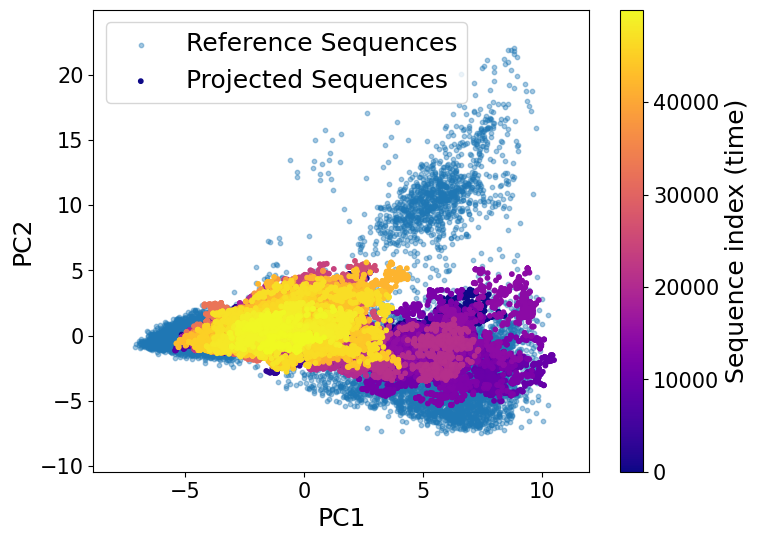

In [48]:
from PCA_func import plot_projected_pca, plot_pca_of_sequences, plot_two_pca_side_by_side, plot_projected_pca_mult, plot_projected_pca_time
plot_projected_pca_time(Z.T,np.array(generated_seqs, dtype=int))

(21, 63)
(21, 63)


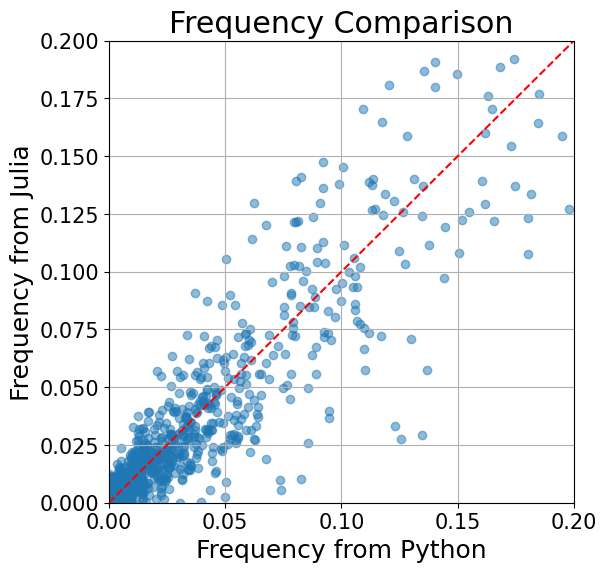

In [49]:
f_train = compute_empirical_freqs(Z, W, q=21)
f_train_flat = f_train.flatten()
print(f_train.shape)

f_gen = compute_empirical_freqs(np.array(generated_seqs.T, dtype=int), None, q=21)
f_gen_flat = f_gen.flatten()
print(f_gen.shape)

# freq-freq plot
plt.figure(figsize=(6,6))
plt.scatter(f_train_flat, f_gen_flat, alpha=0.5)
plt.xlabel('Frequency from Python')
plt.ylabel('Frequency from Julia')
plt.title('Frequency Comparison')
plt.plot([0, 0.2], [0, 0.2], 'r--')  # y=x line
plt.xlim(0, 0.2)
plt.ylim(0, 0.2)
plt.grid()
plt.show()

In [50]:
from hamming_dist import hamming_dist, energy_corr_array
initial_sequence = np.array(generated_seqs[0], dtype=int)
hamming_distances = []
for seq in np.array(generated_seqs,dtype=int):
    distance = hamming_dist(initial_sequence, seq)
    hamming_distances.append(distance)
hamming_distances = np.array(hamming_distances)
correlation = energy_corr_array(hamming_distances, int(len(hamming_distances)/5))

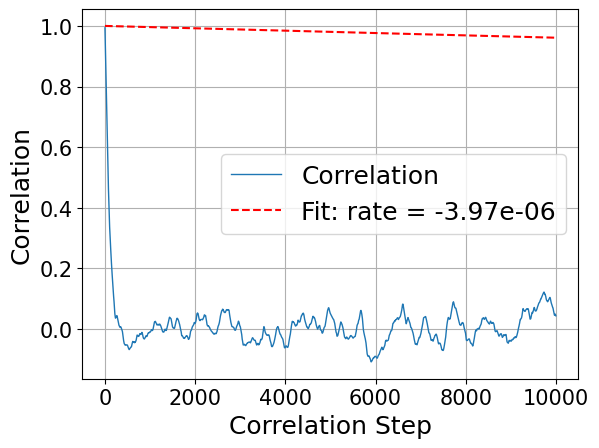

In [51]:

from scipy.stats import linregress
 
def plot_decorrelation(correlation,range,save_path=None):
    x_vals = np.arange(range)  # X values for linear fit (steps)
    y_vals = correlation[:range]  # First 1000 correlation values
    
    # Perform linear fit: y = mx + c, extract the slope (m)
    slope, intercept, r_value, p_value, std_err = linregress(x_vals, np.exp(y_vals))
    
    # Store the slope for this beta
    
    
    # Plot the correlation curve and linear fit
    plt.plot(correlation, marker='', linestyle='-', linewidth=1, label="Correlation")
    plt.plot(np.arange(len(correlation)), np.exp(slope * np.arange(len(correlation))), color='r',linestyle="--", label=f"Fit: rate = {slope:.2e}")
    plt.xlabel("Correlation Step")
    plt.ylabel("Correlation")
    plt.legend()
    plt.grid(True)
    if save_path:
        plt.savefig(save_path)
    plt.show()
    
plot_decorrelation(correlation, int(len(hamming_distances)/5), save_path=None)